In [1]:
import typing as t

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

### Elements of Deep Learning 
- Model 
- Data, with or without labels 
- Optimizer 
- Loss 

## A "network" for multi-class classification

We saw in the previous lab that the two main problems with the perceptron are that it will converge only if the classes are linearly separable and that it can only be used for binary classification.

In this section we are going to create a "network" where the inputs are directly connected to the output layer, in which we have one output unit for each class.

Let's define a *linear layer* as:

$$ \mathbf{z} = W \mathbf{x} + b $$

With $W \in \mathbb{R}^{C \times M} $. $M$ is the dimension of the input and $C$ the number of output units (= number of classes), $\mathbf{x} \in \mathbb{R}^M$ and $b\in \mathbb{R}^C$.

The Softmax function maps a vector $z \in \mathbb{R}^C$ to a vector $q \in \mathbb{R}^C$  such that:

$$ q_i(\mathbf{z}) = \frac{e^{z_i}}{\sum_{j \in {\{1, \ldots, C\}}}{e^{z_j}}} \forall i \in {\{1, \ldots, C\}} = Softmax(\mathbf{z})_i $$

Note that: $ 0 \leq q_i \leq 1 \forall i \in {\{1, \ldots, C\}} $, and: $\sum_{i \in {\{1, \ldots, C\}}}{q_i} = 1 $; therefore we can interpret the Softmax function as a function that can normalize any real vector $\mathbf{z}$  into a probability distribution $\mathbf{q}$ over the $C$ values.

With this setup, a "forward pass" corresponds to calculating $\mathbf{z}$ and applying the Softmax to it.

The implementation of the Softmax and a forward pass is as follows:

In [2]:
def softmax(z: np.ndarray) -> np.ndarray:
    """
    Takes the output of a layer as input and returns a probability distribution
    input:
        z (np.array)

    returns:
        out (np.array)
    """
    # z_stable = z - np.max(z, axis=0, keepdims=True)  # subtract max per column
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)


def forward(W: np.ndarray, b: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Computes the forward pass and returns the softmax
    input:
        W (np.array): (N_CLASSES, INPUT_SHAPE) The weight matrix of the perceptron
        b (np.array): (N_CLASSES, 1) The bias matrix of the perceptron
        x (np.array): (INPUT_SHAPE, 1) The input of the perceptron

    returns:
        (np.array) (C, 1)
    """
    z = W @ x + b

    return softmax(z)

In a supervised classification task, we typically use the cross-entropy function on top of the softmax output as a loss function. We use a 1-hot encoded vector for the true distribution $\mathbf{p}(x)$ , where we have $1$ in the position corresponding to the true label $y$ and $0$ elsewhere:

$$
p_i(x) = \left\{
  \begin{array}{ll}
    1, & \text{if}\ y=i \\
    0, & \text{otherwise}
  \end{array}\right.
$$

and the output of the softmax function as our $\mathbf{q}$.

For a single sample $x$, the cross-entropy loss value for these p(x) and q(x) is then:
$$H(p,q)= − \sum_{i=1}^C{p_i(x)\log q_i(x)}$$

Given that the only non-zero element of the 1-hot vector $p(x)$ is at the $y$ index of the correct class, in practice the $p(x)$ vector is a selector for the $y$ index in the $q(x)$ vector. Therefore, the loss function for a single sample becomes:

$$ Loss = -\log(q_y) = - \log \left( \frac{e^{z_y}}{\sum_{j \in {\{1, \ldots, C\}}}{e^{z_j}}} \right) = - z_y + \log \sum_{j}{e^{z_j}}$$

The gradients of the loss with respect to $W$ and $b$ are respectively

$$\nabla_W Loss = (q-y)x^\top$$
$$\nabla_b Loss = (q-y)$$

_Solution_:

Let's start by calculating the derivative for each $z_i$ :
$$
\begin{aligned}
\nabla_{z_i}Loss &= \nabla_{z_i}\left( - z_y + \log \sum_{j}{e^{z_j}}\right)\\
&= \nabla_{z_i}\log \sum_{j}{e^{z_j}} - \nabla_{z_i}z_y \\
&= \frac{1}{\sum_{j}{e^{z_j}}}\nabla_{z_i}\sum_{j}{e^{z_j}}- \nabla_{z_i}z_y \\
&= \frac{e^{z_i}}{\sum_{j}{e^{z_j}}} - \nabla_{z_i}z_y \\
&= Softmax(z)_i - \nabla_{z_i}z_y \\
&= Softmax(z)_i - \mathbb{1}(y = i)
\end{aligned}
$$

where $\mathbb{1}(y = i)$ is the one-hot encoded vector of the label:
$$
\mathbb{1}(y = i) = \left\{
  \begin{array}{ll}
    1, & \text{if}\ y=i \\
    0, & \text{otherwise}
  \end{array}\right.
$$

From this result we can observe that:

$\nabla_{z_y} Loss = q_y -1 $ : the gradient for the true label's *logit* is non-positive and decrease proportionally in magnitude as $q_y$ increases.

$ \nabla_{z_i} Loss = q_i  \forall i \neq y $: The rest of the logits gradient ($q_i$) will be non-negative and increase proportionally as $q_i$ increases.

In the specific case of perfect classification where $q_y=1$, the gradient will be $0$ and thus none of the network's parameters will be modified.

Gradients are directed towards the maximal value increase of their function. As expected for our loss function, increasing the probability of the true label's class will decrease the loss, and increasing the probability of each of the incorrect classes will increase the loss. Note that the loss will be infinite if the classifier assigns 0 to the true class. In practice, small values are added to avoid such situation, but we are not considering them here.

We can calculate now the gradient with respect to the $i,j$-th coefficient of $W$:
$$
\begin{aligned}
\frac{\partial Loss}{\partial W_{ij}} &= \frac{\partial Loss}{\partial z_i} \frac{\partial z_i}{\partial W_{ij}}\\
&= (\nabla_{z_i}Loss)_i x_j\\
\end{aligned}
$$

in matrix form: $$
(\nabla_{W}Loss)=(q-y)x^\top\\
$$

The gradient with respect to the bias is direct: $\nabla_b Loss = \nabla_{z_i} Loss$

> **Task 1**: Implement the gradients and the loss

In [3]:
def compute_grads(softmaxed: np.ndarray, x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    inputs:
        softmaxed (np.array): (N_CLASSES, batch_size) result of the forward pass
        y (np.array): (N_CLASSES, batch_size) One-hot encoded vector of the label
        x (np.array): (INPUT_SHAPE, batch_size) Input vector

    returns:
        d_W (np.array): (N_CLASSES, INPUT_SHAPE) Gradient of the loss with respect to the weight matrix
        d_b (np.array): (N_CLASSES, 1) Gradient of the loss with respect to the bias matrix
    """

    #YOUR SOLUTION HERE
    d_W = (softmaxed - y) @ x.T
    d_b = np.mean(softmaxed - y, axis = 1, keepdims = True)
    return d_W, d_b


def compute_loss(softmaxed: np.ndarray, y: np.ndarray) -> float:
    """
    loss for a single datapoint
    inputs:
        softmaxed (np.array): (N_CLASSES, batch_size)
        y (np.array): (N_CLASSES, batch_size)

    returns:
        (float)
    """
    #YOUR SOLUTION HERE
    loss = - np.sum(y * np.log(softmaxed), axis=0)
    return float(np.mean(loss))

Now, let's generate some data:

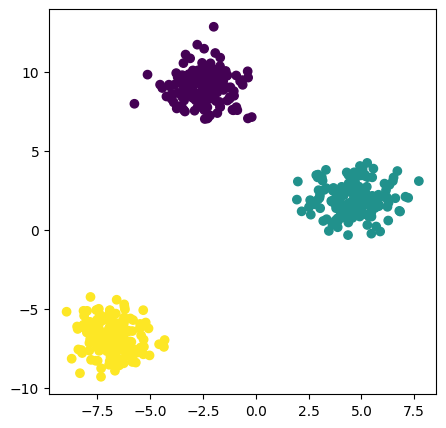

In [4]:
X, Y = make_blobs(n_samples=500, n_features=2, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

# encode output as one-hot
Y = OneHotEncoder(categories="auto").fit_transform(Y.reshape(-1, 1)).toarray()

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, random_state=42, test_size=0.4
)

The following function trains our model:

In [5]:
def train_network(
    X_train, Y_train, X_test, Y_test, lr, n_epochs=10, batch_size=10, random_seed=42
):

    INPUT_SHAPE = X_train.shape[1]
    N_CLASSES = Y_train.shape[1]

    # Initialise metrics lists
    loss_history = []
    acc_history = []
    test_acc_history = []

    # Initialisation of the weights
    np.random.seed(random_seed)
    W = np.random.normal(size=(N_CLASSES, INPUT_SHAPE))
    b = np.random.normal(size=(N_CLASSES, 1))

    n_samples = X_train.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))

    for epoch in range(n_epochs):
        # Shuffle dataset
        idx = np.random.permutation(n_samples)
        X_train = X_train[idx]
        Y_train = Y_train[idx]

        epoch_loss = []
        epoch_acc = []

        for batch_idx in range(n_batches):
            # Mini-batch
            start = batch_idx * batch_size
            end = min((batch_idx + 1) * batch_size, n_samples)

            X_batch = X_train[start:end].T  # (INPUT_SHAPE, batch_size)
            Y_batch = Y_train[start:end].T  # (N_CLASSES, batch_size)

            # Forward pass
            out = forward(W, b, X_batch)

            # Weight update
            d_W, d_b = compute_grads(out, X_batch, Y_batch)
            W -= lr * d_W
            b -= lr * d_b

            # Batch metrics
            epoch_loss.append(compute_loss(out, Y_batch))
            epoch_acc.append(
                np.mean(np.argmax(out, axis=0) == np.argmax(Y_batch, axis=0))
            )

        # --- End of epoch metrics ---
        avg_loss = np.mean(epoch_loss)
        avg_acc = np.mean(epoch_acc)
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        # Test accuracy
        out_test = forward(W, b, X_test.T)
        avg_test_acc = np.mean(
            np.argmax(out_test, axis=0) == np.argmax(Y_test, axis=1)
        )
        test_acc_history.append(avg_test_acc)

    return W, b, loss_history, acc_history, test_acc_history

Now, let's train the model on the data and observe the results:

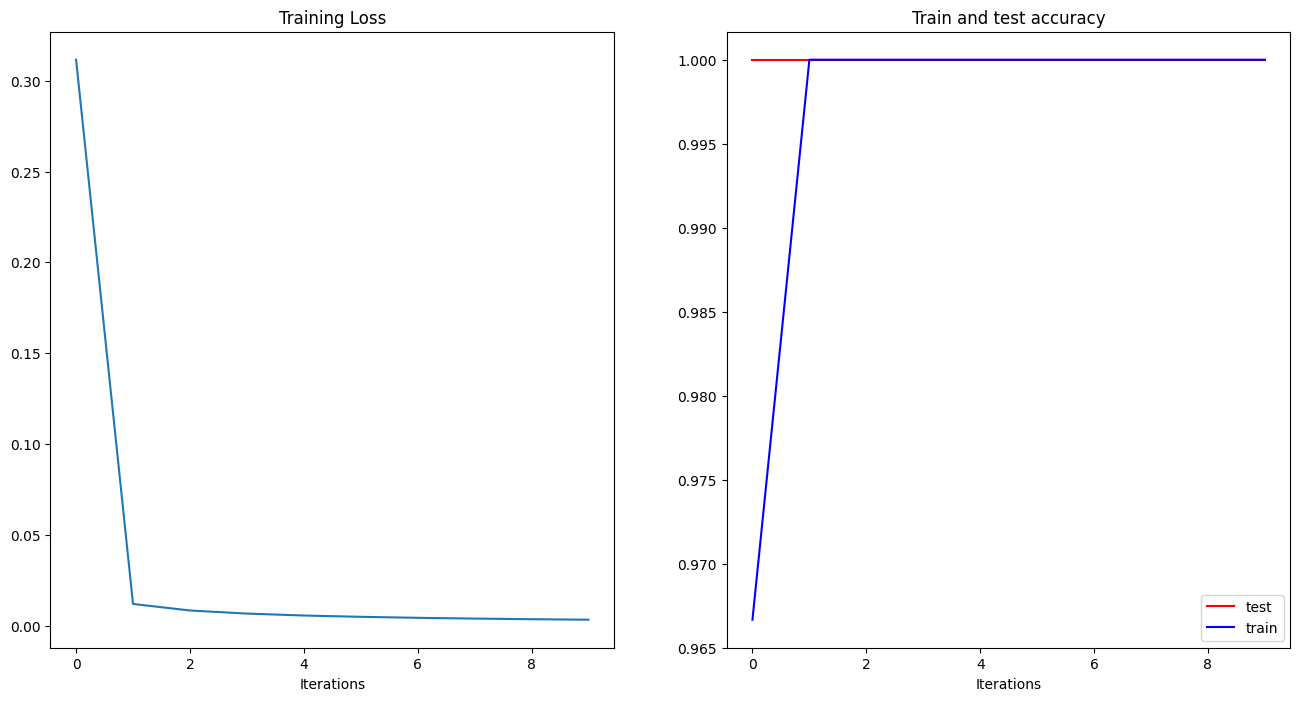

In [6]:
W, b, loss, acc, test_acc = train_network(
    X_train, Y_train, X_test, Y_test, lr=0.01, n_epochs=10
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.plot(loss)
ax1.set_title("Training Loss")
ax1.set_xlabel("Iterations")
ax2.plot(test_acc, c="r", label="test")
ax2.plot(acc, c="b", label="train")
ax2.set_title("Train and test accuracy")
ax2.set_xlabel("Iterations")
plt.legend()
plt.show()


Now we can visualize the decision boundaries:

In [7]:
def plot_decision(X: np.ndarray, Y: np.ndarray, forward_fun: t.Callable, ax=None):
    """
    Plot hard decision regions and scatter data points.

    Parameters
    ----------
    X : np.ndarray, shape (N, 2)
        Features
    Y : np.ndarray, shape (N, C)
        One-hot encoded labels
    forward_fun : function
        Callable that accepts x (shape: (2,1)) and outputs probabilities (C,)
    ax : matplotlib Axes, optional
        Axis to plot on (useful for subplots). If None, a new figure is created.
    """

    # --- Meshgrid over feature space ---
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
    )

    # --- Forward pass for all grid points ---
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    probs = np.array([forward_fun(pt.reshape(-1, 1)).ravel() for pt in grid_points])

    # Hard class assignment
    Z = np.argmax(probs, axis=1).reshape(xx1.shape)

    # --- Create axis if none provided ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Decision surface
    ax.pcolormesh(xx1, xx2, Z, cmap="viridis", shading="auto", alpha=0.6)

    # Data points
    markers = [".", "*", "D", "o", "s", "x"]
    for c in range(Y.shape[1]):
        ax.scatter(
            X[np.argmax(Y, axis=1) == c, 0],
            X[np.argmax(Y, axis=1) == c, 1],
            c="k",
            marker=markers[c % len(markers)],
            label=f"class {c}",
        )

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend()
    return ax

<Axes: xlabel='$x_1$', ylabel='$x_2$'>

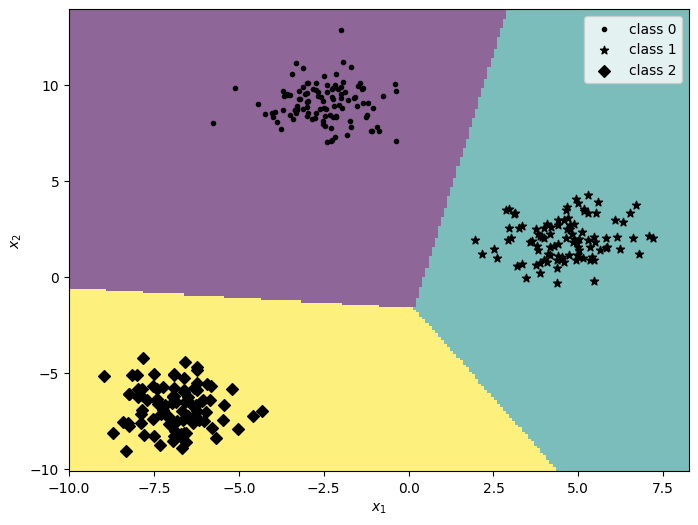

In [8]:
plot_decision(X_train, Y_train, lambda x: forward(W, b, x))

The data we used was linearly separable (can be separated on a hyperplan!), so let's take a look at how our network would perform on a different dataset: 

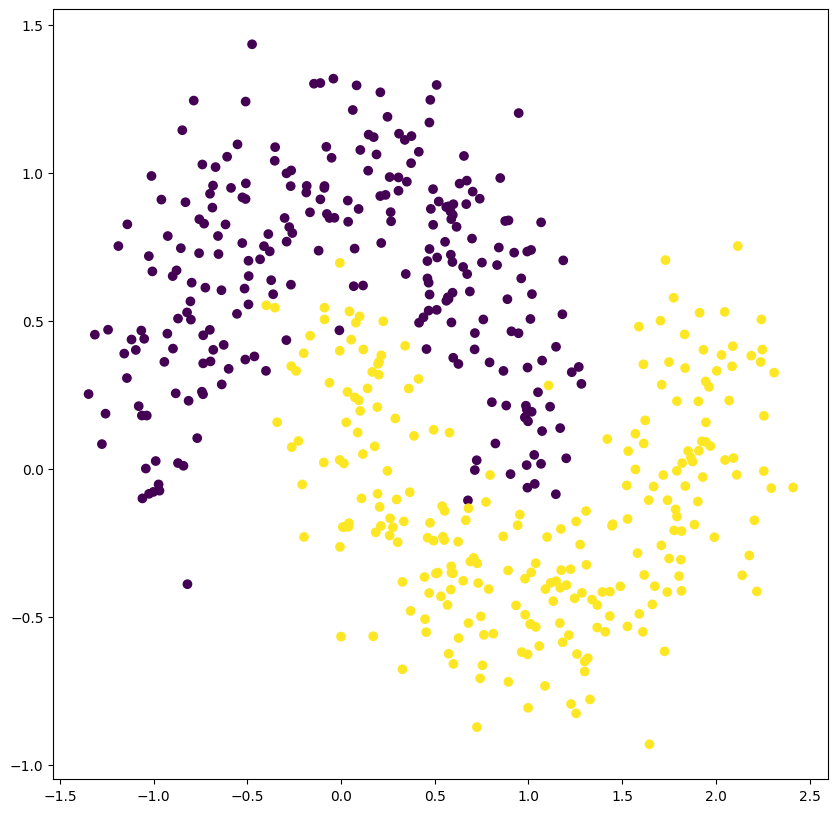

In [9]:
X, Y = make_moons(n_samples=500, noise=0.2)
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()
Y = OneHotEncoder(categories="auto").fit_transform(Y.reshape(-1, 1)).toarray()

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, random_state=42, test_size=0.4
)

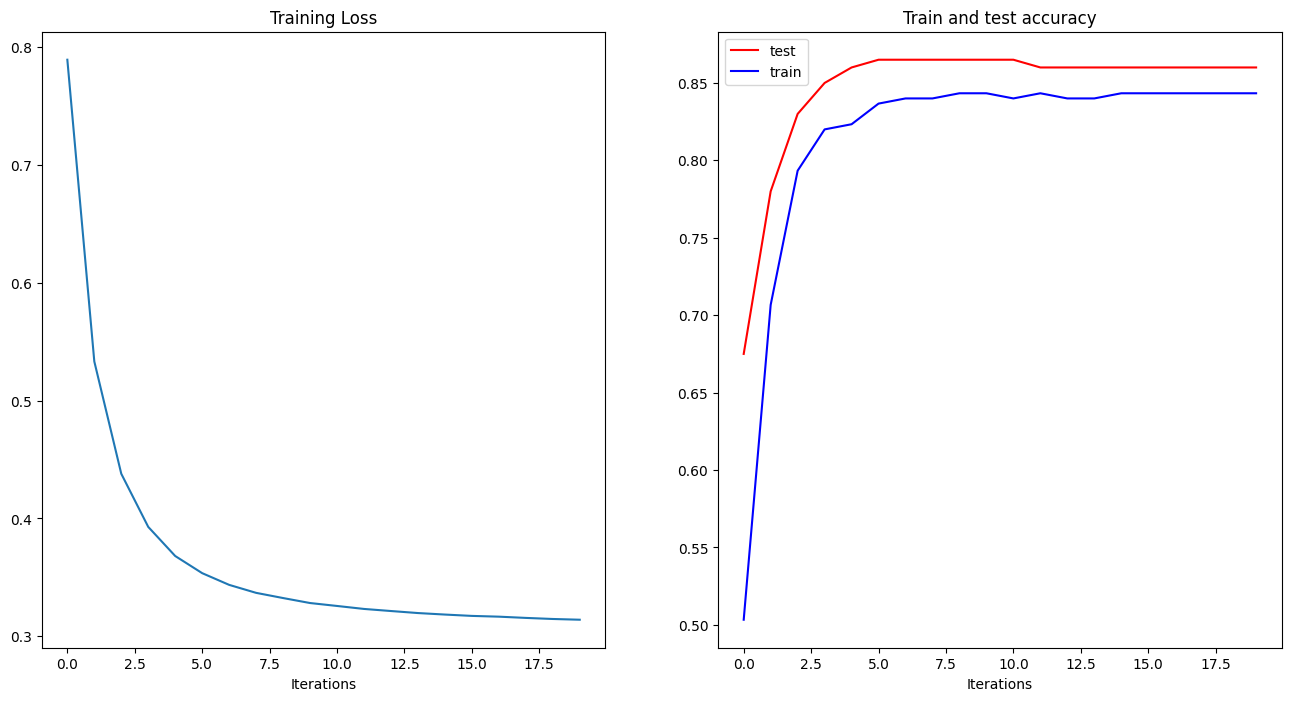

<Axes: xlabel='$x_1$', ylabel='$x_2$'>

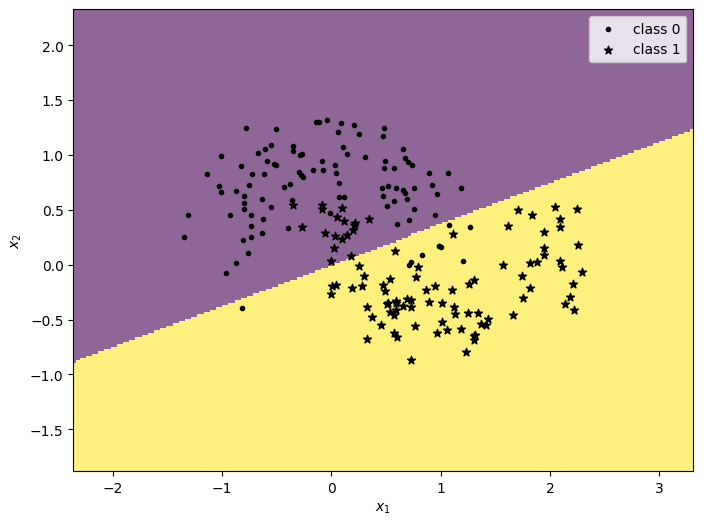

In [10]:
W, b, loss, acc, test_acc = train_network(
    X_train, Y_train, X_test, Y_test, 0.01, n_epochs=20
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.plot(loss)
ax1.set_title("Training Loss")
ax1.set_xlabel("Iterations")
ax2.plot(test_acc, c="r", label="test")
ax2.plot(acc, c="b", label="train")
ax2.set_title("Train and test accuracy")
ax2.set_xlabel("Iterations")
plt.legend()
plt.show()
plot_decision(X_test, Y_test, lambda x: forward(W, b, x))

`We get this kind of boundary that is linear but not that good (the data is linearly inseparable) because we dont have hidden layers. It is a logistic regression, thus linear and is not what we want.`

# A "real" neural network

Actually our "network" until now was nothing else than multinomial Logistic Regression. Therefore, to obtain a non-linear decision boundary, we need at least one **hidden layer** with a non-linear activation function; in this case we are going to study a case in which the activation chosen for the hidden layer is the $ReLU$ function:

$$ z = W x + b_1 $$

$$ h = ReLU(W x + b_1) = ReLU(z) $$

We will use the Softmax seen in the previous case as the output layer:

$$ \theta = U h + b_2 $$

$$ \hat{y} = Softmax(\theta) $$

With $U \in \mathbb{R}^{C \times H}$ and $W \in \mathbb{R}^{H \times M}$ and $b_1$, $b_2$ vectors of corresponding dimensions. $H$ is the number of hidden units.

The $ReLU$ function is defined as:

$$ ReLU(x) = 
\begin{cases}
0 \textrm{ if } x < 0\\
x \textrm{ otherwise }
\end{cases}
$$

and it's immediate to observe that the derivative of the ReLU function is: $sgn(ReLU(x)) $.

> **Task 2**: Implement the ReLU activation function, the derivative of the relu, and the forward pass for the neural network.

In [11]:
def relu(x: np.ndarray) -> np.ndarray:
    """
    input:
        x (np.array)

    returns:
        x (np.array)
    """
    #YOUR SOLUTION HERE
    # resultat = 0 if x < 0 else x
    # return resultat
    return np.clip(x, 0, np.inf)

def d_relu(x: np.ndarray) -> np.ndarray:
    """Computes the derivative of the relu
    input:
        x (np.array)

    returns:
        x (np.array)
    """
    #YOUR SOLUTION HERE
    # if x < 0 :
    #     res = 0 
    # else :
    #     res = 1
    # return res
    return (x > 0).astype(int)

def forward_NN(
    U: np.ndarray, b2: np.ndarray, W: np.ndarray, b1: np.ndarray, x: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Forward pass of a two layer perceptron with relu activation
    input:
        W (np.array): (HIDDEN_SHAPE, INPUT_SHAPE) The weight matrix of the hidden layer
        U (np.array): (N_CLASSES, HIDDEN_SHAPE) The weight matrix of the output layer
        b1 (np.array): (HIDDEN_SHAPE, 1) The bias matrix of the hidden layer
        b2 (np.array): (N_CLASSES, 1) The bias matrix of the output layer
        x (np.array): (INPUT_SHAPE, 1) The input of the perceptron

    returns:
        softmaxed (np.array): (N_CLASSES, 1) the output of the network after final activation
        hidden (np.array): (HIDDENT_SHAPE, 1) the output of the hidden layer after activation
        out (np.array): (N_CLASSES, 1) the output of the network before final activation
    """
    #YOUR SOLUTION HERE
    hidden = relu(W @ x + b1)
    out = U @ hidden + b2
    return softmax(out), hidden, out

Putting all of the above together, we can see that:


$$ q_i(\mathbf{\theta}) = \frac{e^{\theta_i}}{\sum_{j \in {\{1, \ldots, C\}}}{e^{\theta_j}}} \forall i \in {\{1, \ldots, C\}} = Softmax(\mathbf{\theta})_i = \hat{y}_i$$

and therefore the loss for a single datapoint is:

$$
Loss = -\log(\hat{y}_y) = - \log \left( \frac{e^{\theta_y}}{\sum_{j \in {\{1, \ldots, C\}}}{e^{\theta_j}}} \right) = - \theta_y + \log \sum_{j}{e^{\theta_j}}$$

We show the calculation of the gradients of the loss with respect to $W$, $U$, $b_1$ and $b_2$

_Solution_:


let's write the chain rule for $\frac{\partial Loss}{\partial U}$ and $\frac{\partial Loss}{\partial b_2}$:

$$
\frac{\partial Loss}{\partial U} = \frac{\partial Loss}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial \theta}\frac{\partial \theta}{\partial U}
$$
$$
\frac{\partial Loss}{\partial b_2} = \frac{\partial Loss}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial \theta}\frac{\partial \theta}{\partial b_2}
$$

Notice that $\frac{\partial Loss}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial \theta} = \frac{\partial Loss}{\partial \theta}$ is present in both derivatives. We will define some variables to represent the intermediate derivatives:

$$
\delta_1 = \frac{\partial Loss}{\partial \theta} ; \hspace{1cm} \delta_2 = \frac{\partial Loss}{\partial z}
$$

These can be thought as the **error signals** passed down to $\theta$ and $z$ when doing backpropagation. We can compute them as follows:

$$
\delta_1 = \frac{\partial Loss}{\partial \theta} = (Softmax(\theta) - y)^\top
$$

as from the loss of the LogReg classifier above; and

$$
\begin{aligned}
\delta_2 &= \frac{\partial Loss}{\partial z} = \frac{\partial Loss}{\partial \theta}\frac{\partial \theta}{\partial h}\frac{\partial h}{\partial z}\\
&= \delta_1 \frac{\partial \theta}{\partial h}\frac{\partial h}{\partial z}\\
&= \delta_1 U \frac{\partial h}{\partial z}\\
&= \delta_1 U \circ sgn(h)\\
\end{aligned}
$$

Now we can use the error terms to compute our gradients.

$$
\frac{\partial Loss}{\partial U} = \frac{\partial Loss}{\partial \theta} \frac{\partial \theta}{\partial U} = \delta_1 \frac{\partial \theta}{\partial U} = \delta_{1}^\top h^\top
$$
$$
\frac{\partial Loss}{\partial b_2} = \frac{\partial Loss}{\partial \theta} \frac{\partial \theta}{\partial b_2} = \delta_1 \frac{\partial \theta}{\partial b_2} = \delta_{1}^\top
$$
$$
\frac{\partial Loss}{\partial W} = \frac{\partial Loss}{\partial z} \frac{\partial z}{\partial W} = \delta_2 \frac{\partial z}{\partial W} = \delta_{2}^\top x^\top
$$
$$
\frac{\partial Loss}{\partial b_1} = \frac{\partial Loss}{\partial z} \frac{\partial z}{\partial b_1} = \delta_2 \frac{\partial z}{\partial b_1} = \delta_{2}^\top
$$


> **Task 3**: Based on the previous result implement the computation of the gradients.

In [12]:
def compute_grads_NN(
    hidden: np.ndarray,
    softmaxed: np.ndarray,
    U: np.ndarray,
    X_batch: np.ndarray,
    Y_batch: np.ndarray,
    W: np.ndarray,
    b1: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Computes gradients for a two-layer NN with ReLU, batch-aware.

    input:
        hidden (np.array): (HIDDEN_SHAPE, batch_size) hidden layer activations
        softmaxed (np.array): (N_CLASSES, batch_size) output after softmax
        U (np.array): (N_CLASSES, HIDDEN_SHAPE) weights of output layer
        X_batch (np.array): (INPUT_SHAPE, batch_size) batch of inputs
        Y_batch (np.array): (N_CLASSES, batch_size) batch of targets
        W (np.array): (HIDDEN_SHAPE, INPUT_SHAPE) weights of hidden layer
        b1 (np.array): (HIDDEN_SHAPE, 1) biases of hidden layer

    returns:
        d_U (np.array): (N_CLASSES, HIDDEN_SHAPE) gradient wrt U
        d_b2 (np.array): (N_CLASSES, 1) gradient wrt b2
        d_W (np.array): (HIDDEN_SHAPE, INPUT_SHAPE) gradient wrt W
        d_b1 (np.array): (HIDDEN_SHAPE, 1) gradient wrt b1
    """
    #YOUR SOLUTION HERE
    batch_size = X_batch.shape[1]

    z = W @ X_batch + b1

    sigma1 = (softmaxed - Y_batch).T

    sigma2 = (sigma1 @ U) * d_relu(z.T)
    d_U = (sigma1.T @ hidden.T)/batch_size

    d_b2 = np.mean(sigma1.T, axis = 1, keepdims= True)

    d_W = (sigma2.T @ X_batch.T)/batch_size

    d_b1 = np.mean(sigma2.T, axis = 1, keepdims= True)
    
    return d_U, d_b2, d_W, d_b1

The following function trains the network:

In [13]:
def train_NN(
    X_train,
    Y_train,
    X_test,
    Y_test,
    lr,
    n_hidden,
    forward_NN,
    compute_grads_NN,
    n_epochs=100,
    batch_size=10,
    random_seed=42,
):

    HIDDEN_SHAPE = n_hidden
    INPUT_SHAPE = X_train.shape[1]
    N_CLASSES = Y_train.shape[1]

    # Initialise metrics lists
    loss_history = []
    acc_history = []
    test_acc_history = []

    # Initialisation of the weights
    np.random.seed(random_seed)
    b1 = np.random.normal(size=(HIDDEN_SHAPE, 1))
    W = np.random.normal(size=(HIDDEN_SHAPE, INPUT_SHAPE))
    b2 = np.random.normal(size=(N_CLASSES, 1))
    U = np.random.normal(size=(N_CLASSES, HIDDEN_SHAPE))

    n_samples = X_train.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))

    for epoch in range(n_epochs):
        # Shuffle dataset
        idx = np.random.permutation(n_samples)
        X_train = X_train[idx]
        Y_train = Y_train[idx]

        epoch_loss = []
        epoch_acc = []

        for batch_idx in range(n_batches):
            # Mini-batch
            start = batch_idx * batch_size
            end = min((batch_idx + 1) * batch_size, n_samples)
            X_batch = X_train[start:end].T  # (INPUT_SHAPE, batch_size)
            Y_batch = Y_train[start:end].T  # (N_CLASSES, batch_size)

            # Forward pass
            softmaxed, hidden, _ = forward_NN(U, b2, W, b1, X_batch)

            # Backprop
            d_U, d_b2, d_W, d_b1 = compute_grads_NN(
                hidden, softmaxed, U, X_batch, Y_batch, W, b1
            )

            # Update
            b1 -= lr * d_b1
            W -= lr * d_W
            b2 -= lr * d_b2
            U -= lr * d_U

            # Batch metrics
            epoch_loss.append(compute_loss(softmaxed, Y_batch))
            epoch_acc.append(
                np.mean(np.argmax(softmaxed, axis=0) == np.argmax(Y_batch, axis=0))
            )

        # --- End of epoch metrics ---
        avg_loss = np.mean(epoch_loss)
        avg_acc = np.mean(epoch_acc)
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        # Test accuracy
        softmaxed_test, _, _ = forward_NN(U, b2, W, b1, X_test.T)
        avg_test_acc = np.mean(
            np.argmax(softmaxed_test, axis=0) == np.argmax(Y_test, axis=1)
        )
        test_acc_history.append(avg_test_acc)

        # print(f"Epoch {epoch+1}/{n_epochs} - "
        #      f"Train Loss: {avg_loss:.4f}, "
        #      f"Train Acc: {avg_acc:.4f}, "
        #      f"Test Acc: {avg_test_acc:.4f}")

    return U, b2, W, b1, loss_history, acc_history, test_acc_history

Let's verify the gradients vs. those calculated by PyTorch autograd. If our manual backpropagation is correct, both results must match up to floating-point precision.

In [14]:
import torch

np.random.seed(0)
H, M, C, B = 16, X_train.shape[1], Y_train.shape[1], 10 #to keep track of sizes
W, b1 = np.random.normal(size=(H, M)), np.random.normal(size=(H, 1))
U, b2 = np.random.normal(size=(C, H)), np.random.normal(size=(C, 1))
X_batch, Y_batch = X_train[:B].T, Y_train[:B].T  # (M, B), (C, B)

# Our gradients
softmaxed, hidden, _ = forward_NN(U, b2, W, b1, X_batch)
ours = compute_grads_NN(hidden, softmaxed, U, X_batch, Y_batch, W, b1)

# PyTorch gradients (float64 to compare at high precision)
params = [torch.tensor(p, dtype=torch.float64, requires_grad=True) for p in (U, b2, W, b1)]
U_t, b2_t, W_t, b1_t = params
x_t = torch.tensor(X_batch, dtype=torch.float64)
y_t = torch.tensor(Y_batch, dtype=torch.float64)

#we calculate the logits and the loss and finally we calculate the gradient
logits = U_t @ torch.relu(W_t @ x_t + b1_t) + b2_t          # (C, B)
loss = -(y_t * torch.log_softmax(logits, dim=0)).sum(dim=0).mean()
loss.backward()

for name, g_ours, p in zip(["U", "b2", "W", "b1"], ours, params):
    g_torch = p.grad.numpy()
    print(f"{name:>2}: max abs diff = {np.max(np.abs(g_ours - g_torch)):.2e}  "
          f"match = {np.allclose(g_ours, g_torch)}")

 U: max abs diff = 3.33e-16  match = True
b2: max abs diff = 0.00e+00  match = True
 W: max abs diff = 5.55e-17  match = True
b1: max abs diff = 1.11e-16  match = True


Now let's train our network on the full dataset:

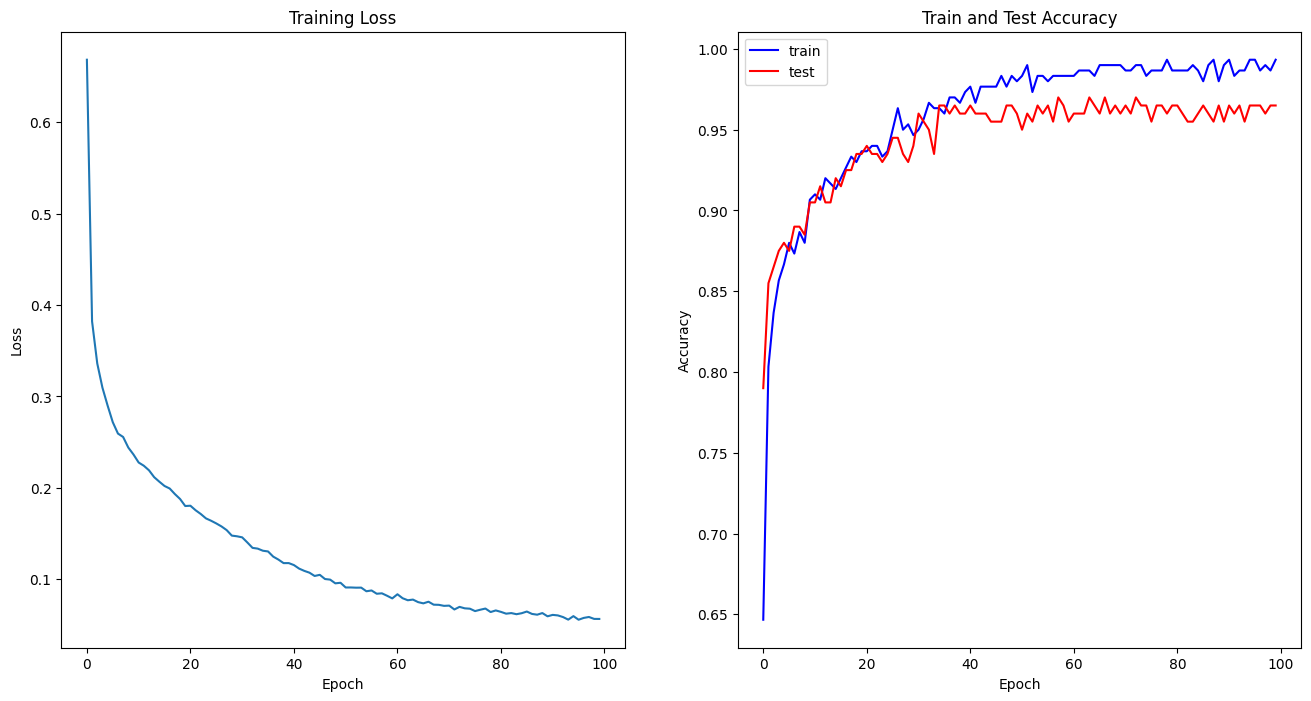

In [15]:
U, b2, W, b1, loss, acc, test_acc = train_NN(
    X_train,
    Y_train,
    X_test,
    Y_test,
    lr=0.1,
    n_hidden=16,
    forward_NN=forward_NN,
    compute_grads_NN=compute_grads_NN,
)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Training loss per epoch
ax1.plot(loss, linestyle="-")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Accuracy per epoch
ax2.plot(acc, c="b", label="train", linestyle="-")
ax2.plot(test_acc, c="r", label="test", linestyle="-")
ax2.set_title("Train and Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.show()

<Axes: xlabel='$x_1$', ylabel='$x_2$'>

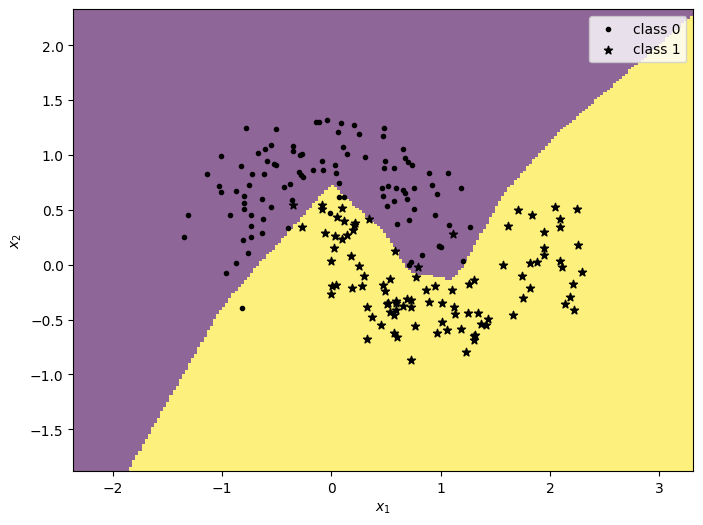

In [16]:
plot_decision(X_test, Y_test, lambda x: forward_NN(U, b2, W, b1, x)[0])

Let's verify how the network performs if we modify the size of the hidden layer (2, 4, 8, 16 hidden units):

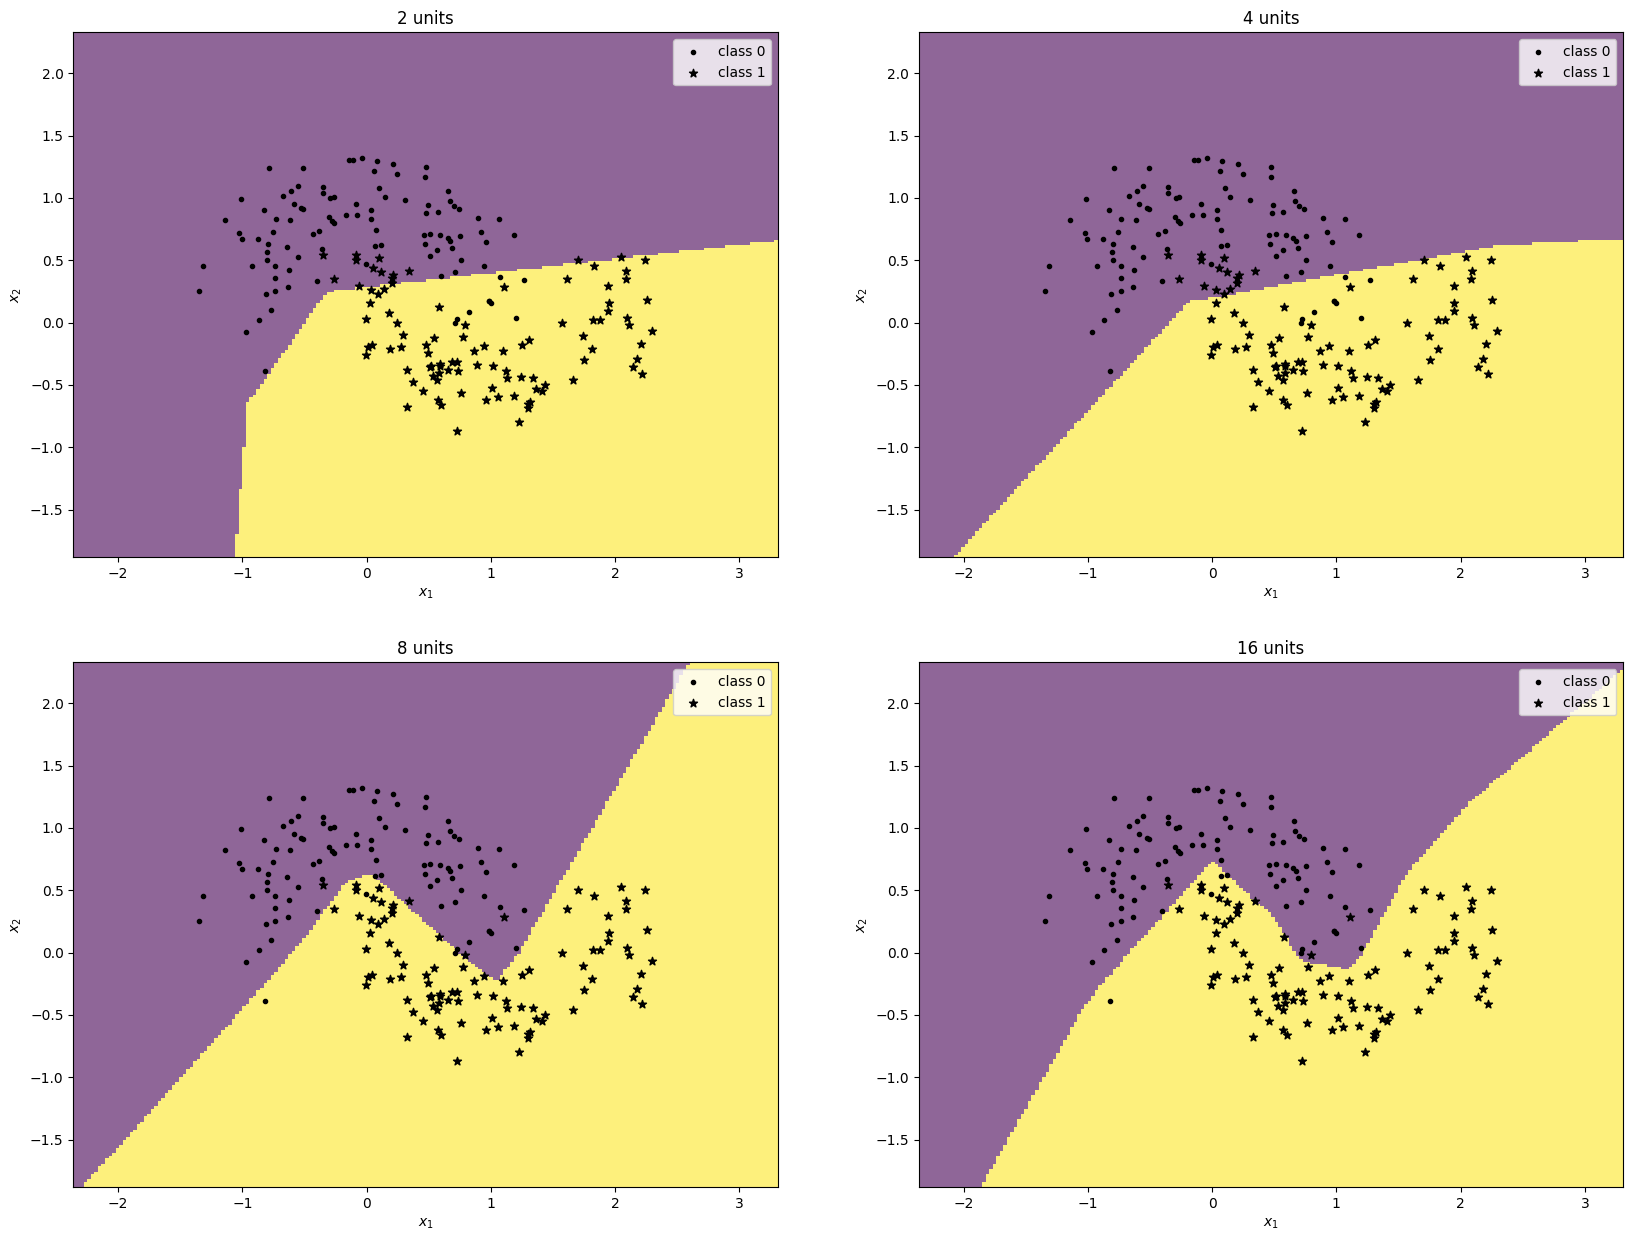

In [17]:
plt.figure(figsize=(20, 15))
for i, n_units in enumerate([2, 4, 8, 16]):
    U, b2, W, b1, loss, acc, test_acc = train_NN(
        X_train,
        Y_train,
        X_test,
        Y_test,
        0.1,
        n_units,
        forward_NN=forward_NN,
        compute_grads_NN=compute_grads_NN,
    )
    plot_decision(
        X_test,
        Y_test,
        lambda x: forward_NN(U, b2, W, b1, x)[0],
        plt.subplot(2, 2, i + 1, title="%i units" % n_units),
    )

### The decision boundary is piecewise linear here on the second picture (4 units) because we use ReLU activation function !!!!

> **Task 4**: Dead ReLU units - how does the learning rate affect the number of *dead units*? Implement the `count_dead_units` function below.

A hidden unit is "dead" when its ReLU outputs 0 for every training sample:
its gradient is then always 0 and `it can never recover!!!!!!`.

Dead units at init: 4/32
lr=0.01  dead= 4/32  test acc=0.915
lr=0.1   dead= 4/32  test acc=0.950
lr=0.5   dead= 4/32  test acc=0.960
lr=1     dead= 4/32  test acc=0.965
lr=2     dead= 8/32  test acc=0.935
lr=3     dead=11/32  test acc=0.880


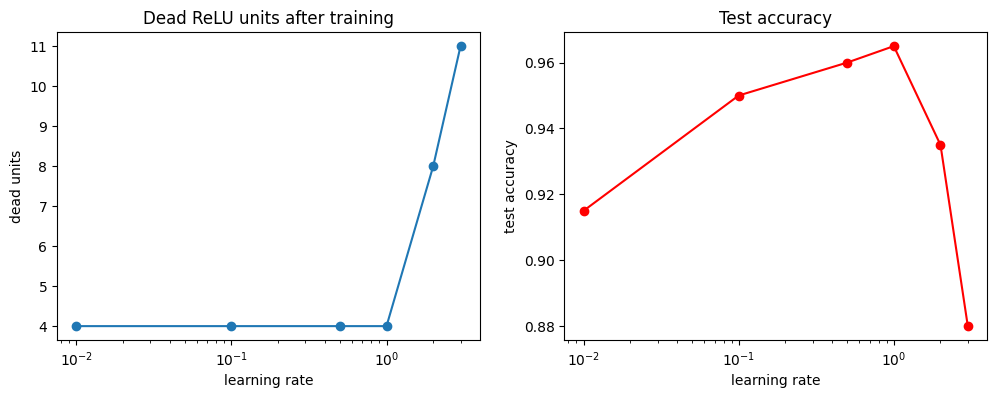

In [18]:
def count_dead_units(W, b1, X):
    """Number of hidden units whose ReLU output is 0 for all samples in X (N, INPUT_SHAPE)."""
    #YOUR SOLUTION HERE
    z = X @ W.T + b1.reshape(-1)
    deads = np.all(z <= 0, axis = 0)
    return np.sum(deads)

N_HIDDEN = 32
learning_rates = [0.01, 0.1, 0.5, 1, 2, 3]

# Dead units at initialisation (n_epochs=0 returns the initial weights)
_, _, W0, b10, *_ = train_NN(X_train, Y_train, X_test, Y_test, 0.1, N_HIDDEN,
                              forward_NN, compute_grads_NN, n_epochs=0)
print(f"Dead units at init: {count_dead_units(W0, b10, X_train)}/{N_HIDDEN}")

dead, test_accs = [], []
for lr in learning_rates:
    U, b2, W, b1, loss, acc, test_acc = train_NN(
        X_train, Y_train, X_test, Y_test, lr, N_HIDDEN,
        forward_NN, compute_grads_NN, n_epochs=50,
    )
    dead.append(count_dead_units(W, b1, X_train))
    test_accs.append(test_acc[-1])
    print(f"lr={lr:<5} dead={dead[-1]:>2}/{N_HIDDEN}  test acc={test_accs[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(learning_rates, dead, "o-")
ax1.set(xscale="log", xlabel="learning rate", ylabel="dead units", title="Dead ReLU units after training")
ax2.plot(learning_rates, test_accs, "o-", c="r")
ax2.set(xscale="log", xlabel="learning rate", ylabel="test accuracy", title="Test accuracy")
plt.show()

We would like now to study the effect of using a different activation function. We will change ReLU to the hyperbolic tangent activation (or *tanh*):

$$
tanh(x) = \frac{e^{2x}-1}{e^{2x}+1}
$$

(Note: you may use the Numpy implementation of tanh)

with derivative (necessary to update the gradient computation): $ tanh'(x) =  1 - tanh(x)^2$ 


> **Task 5**: Update the forward pass and gradient computation of our neural network implementation to use the tanh activation function and vizualize the result.

In [19]:
def forward_tanh(
    U: np.ndarray, b2: np.ndarray, W: np.ndarray, b1: np.ndarray, X_batch: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Forward pass of a two-layer perceptron with tanh activation
    input:
        W (HIDDEN_SHAPE, INPUT_SHAPE)
        U (N_CLASSES, HIDDEN_SHAPE)
        b1 (HIDDEN_SHAPE, 1)
        b2 (N_CLASSES, 1)
        X_batch (INPUT_SHAPE, batch_size)
    returns:
        softmaxed (N_CLASSES, batch_size)
        hidden (HIDDEN_SHAPE, batch_size)
        out (N_CLASSES, batch_size)
    """
    #YOUR SOLUTION HERE
    #batch_size = X_batch.shape[1]
    hidden = np.tanh(W @ X_batch + b1)
    out = U @ hidden + b2
    return softmax(out), hidden, out


def compute_grads_tanh(
    hidden: np.ndarray,
    softmaxed: np.ndarray,
    U: np.ndarray,
    X_batch: np.ndarray,
    Y_batch: np.ndarray,
    W: np.ndarray,
    b1: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Batch-aware gradients for tanh activation

    input:
        hidden (np.array): (HIDDEN_SHAPE, batch_size) hidden layer activations
        softmaxed (np.array): (N_CLASSES, batch_size) output after softmax
        U (np.array): (N_CLASSES, HIDDEN_SHAPE) weights of output layer
        X_batch (np.array): (INPUT_SHAPE, batch_size) batch of inputs
        Y_batch (np.array): (N_CLASSES, batch_size) batch of targets
        W (np.array): (HIDDEN_SHAPE, INPUT_SHAPE) weights of hidden layer
        b1 (np.array): (HIDDEN_SHAPE, 1) biases of hidden layer

    returns:
        d_U (np.array): (N_CLASSES, HIDDEN_SHAPE) gradient wrt U
        d_b2 (np.array): (N_CLASSES, 1) gradient wrt b2
        d_W (np.array): (HIDDEN_SHAPE, INPUT_SHAPE) gradient wrt W
        d_b1 (np.array): (HIDDEN_SHAPE, 1) gradient wrt b1
    """
    #YOUR SOLUTION HERE
    batch_size = X_batch.shape[1]

    z = W @ X_batch + b1

    sigma1 = (softmaxed - Y_batch).T

    sigma2 = (sigma1 @ U) * d_relu(z.T)
    d_U = (sigma1.T @ hidden.T)/batch_size

    d_b2 = np.mean(sigma1.T, axis = 1, keepdims= True)

    d_W = (sigma2.T @ X_batch.T)/batch_size

    d_b1 = np.mean(sigma2.T, axis = 1, keepdims= True)
    
    return d_U, d_b2, d_W, d_b1

Visualisation of boundary:

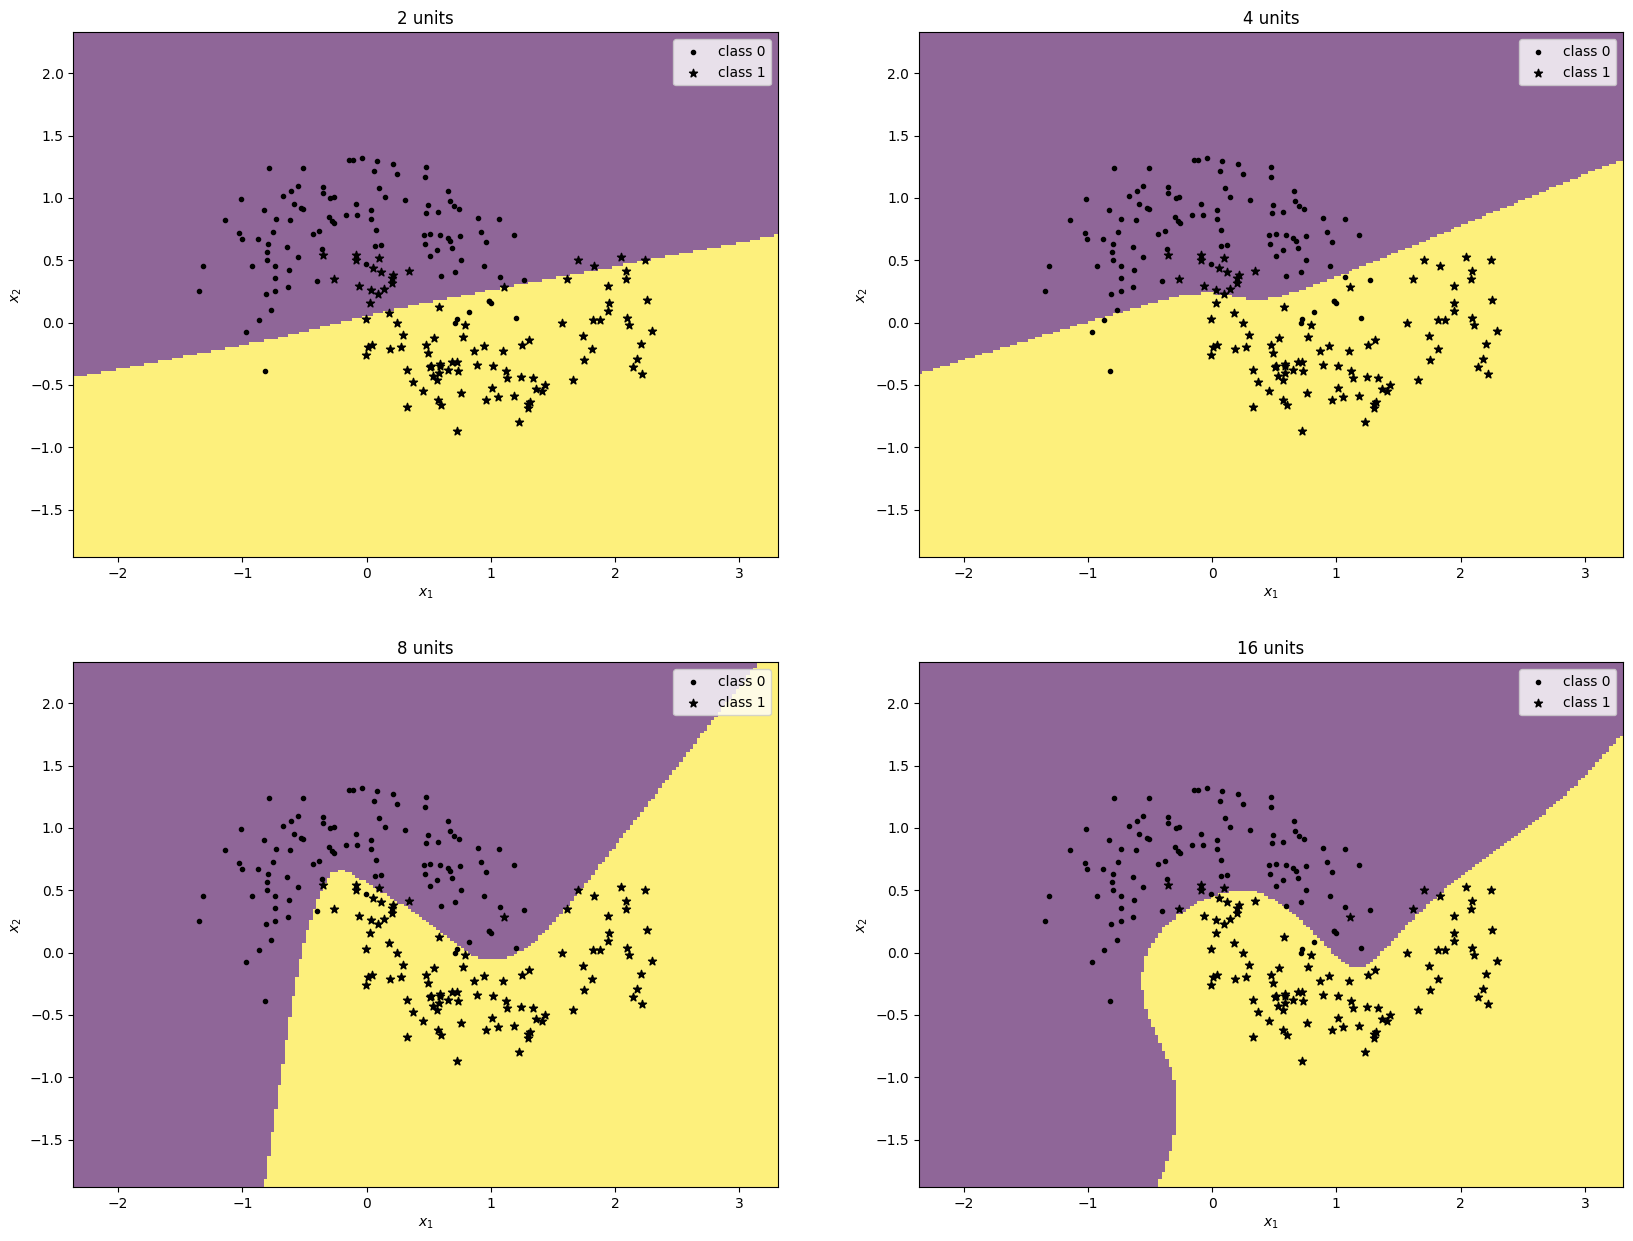

In [20]:
plt.figure(figsize=(20, 15))
for i, n_units in enumerate([2, 4, 8, 16]):
    U, b2, W, b1, loss, acc, test_acc = train_NN(
        X_train,
        Y_train,
        X_test,
        Y_test,
        0.1,
        n_units,
        forward_NN=forward_tanh,
        compute_grads_NN=compute_grads_tanh,
    )
    plot_decision(
        X_test,
        Y_test,
        lambda x: forward_tanh(U, b2, W, b1, x)[0],
        plt.subplot(2, 2, i + 1, title="%i units" % n_units),
    )

plt.show()

> **Task 6**: Re-run the Task 4 experiments with tanh activations. In this case we don't count dead units but *saturated* units (i.e. units with $|tanh(z)|>0.99$ on nearly all samples. Implement this count for 90% of samples.What do you observe?


In [21]:
def count_saturated_units(W, b1, X, threshold=0.99, frac=0.9):
    """Tanh units with |tanh(z)| > threshold on more than `frac` of the samples."""
    #YOUR SOLUTION HERE
    z = X @ W.T + np.reshape(b1, (1,-1))
    out = np.tanh(z)
    saturated_frac = np.mean(np.abs(out) > threshold, axis=0)  
    return int(np.sum(saturated_frac > frac))

##### `tanh` squashes any input into the range (-1, 1). When the input z is large in magnitude, the output is already very close to 1 or -1, and the curve is almost flat there. The derivative of tanh is 1 - tanh(z)², which is nearly zero in that region. During backpropagation, the gradient passing through that unit gets multiplied by this tiny number, so the weights feeding into it barely update. A unit that is in this flat region for almost every input is effectively frozen, and it contributes little beyond a constant. That is what "saturated" means here, and it often happens when weights are initialized too large or inputs aren't normalized.

Saturated units at init: 0/32
lr=0.01  saturated= 0/32  test acc=0.870
lr=0.1   saturated= 0/32  test acc=0.955
lr=0.5   saturated= 0/32  test acc=0.945
lr=1     saturated= 8/32  test acc=0.930
lr=2     saturated= 3/32  test acc=0.785
lr=3     saturated=12/32  test acc=0.860


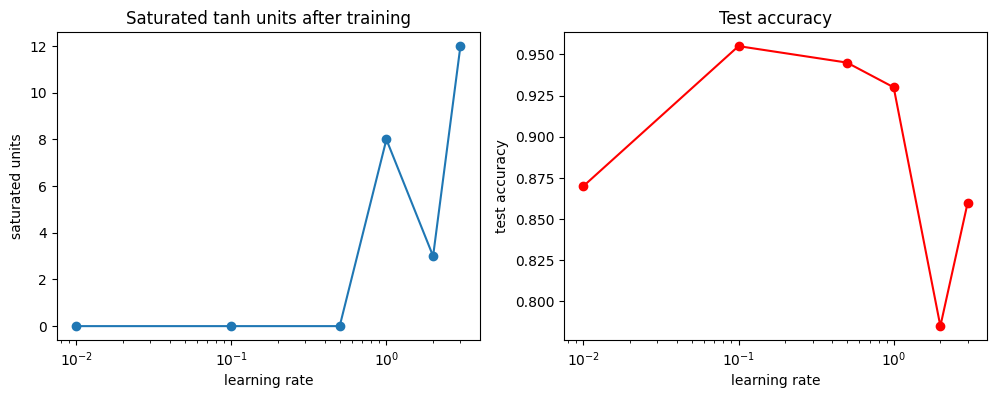

In [22]:
N_HIDDEN = 32
learning_rates = [0.01, 0.1, 0.5, 1, 2, 3]


# Dead units at initialisation (n_epochs=0 returns the initial weights)
_, _, W0, b10, *_ = train_NN(X_train, Y_train, X_test, Y_test, 0.1, N_HIDDEN,
                              forward_tanh, compute_grads_NN, n_epochs=0)
print(f"Saturated units at init: {count_saturated_units(W0, b10, X_train)}/{N_HIDDEN}")

saturated, test_accs = [], []
for lr in learning_rates:
    U, b2, W, b1, loss, acc, test_acc = train_NN(
        X_train, Y_train, X_test, Y_test, lr, N_HIDDEN,
        forward_tanh, compute_grads_NN, n_epochs=50,
    )
    saturated.append(count_saturated_units(W, b1, X_train))
    test_accs.append(test_acc[-1])
    print(f"lr={lr:<5} saturated={saturated[-1]:>2}/{N_HIDDEN}  test acc={test_accs[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(learning_rates, saturated, "o-")
ax1.set(xscale="log", xlabel="learning rate", ylabel="saturated units", title="Saturated tanh units after training")
ax2.plot(learning_rates, test_accs, "o-", c="r")
ax2.set(xscale="log", xlabel="learning rate", ylabel="test accuracy", title="Test accuracy")
plt.show()

## Bonus: Why can SGD converge at all?

Task 6 showed that the learning rate controls how far SGD moves. A second question remains:

> If each stochastic gradient is noisy, why should SGD move towards a minimum at all?

### 1. Correct on average is not enough

Let $f(\mathbf w)$ be the full objective and let $\mathbf g_t$ be the stochastic gradient at
iteration $t$.

Under uniform sampling with replacement, a standard assumption is

$$
\mathbb E[\mathbf g_t\mid\mathbf w_t]
=
\nabla f(\mathbf w_t).
$$

The expectation averages over the randomly sampled example or minibatch while treating the current
parameters $\mathbf w_t$ as fixed. Thus, the stochastic gradient points in the correct direction
**on average**. An individual step may still point in an unhelpful direction, so unbiasedness alone
does not guarantee convergence.

### 2. Smooth objectives make local steps more predictable

The objective is **$L$-smooth** if its gradient cannot change faster than some constant $L$:

$$
\|\nabla f(\mathbf v)-\nabla f(\mathbf w)\|
\leq
L\|\mathbf v-\mathbf w\|.
$$

Intuitively, $L$ limits how quickly the slope can change. A larger $L$ permits stronger curvature,
so a smaller step may be needed.

$L$ is a property of the objective. A valid value must make the smoothness inequality true for every pair of points in the region being
considered. If the following supremum is finite, it is the smallest valid value:

$$
L_{\min}
=
\sup_{\mathbf v\neq\mathbf w}
\frac{\|\nabla f(\mathbf v)-\nabla f(\mathbf w)\|}
{\|\mathbf v-\mathbf w\|}.
$$

For a twice-differentiable scalar objective, a common way to find a valid bound is
$L\geq\sup_w|f''(w)|$. In several dimensions, the corresponding check bounds the largest
absolute curvature using the operator norm of the Hessian. For a neural-network objective, an
exact finite global constant may be difficult to establish, so smoothness is often stated as an
assumption or considered over a relevant region. When a bound is known, overestimating $L$
preserves validity but produces a looser bound.

Smoothness gives the upper bound

$$
f(\mathbf v)
\leq
f(\mathbf w)
+\nabla f(\mathbf w)^\top(\mathbf v-\mathbf w)
+\frac{L}{2}\|\mathbf v-\mathbf w\|^2.
$$

The three parts on the right are:

1. $f(\mathbf w)$: the current objective value;
2. $\nabla f(\mathbf w)^\top(\mathbf v-\mathbf w)$: the tangent, or first-order prediction;
3. $\frac{L}{2}\|\mathbf v-\mathbf w\|^2$: a curvature allowance for what the tangent misses.

The bound does not say that the objective is quadratic. It says that an $L$-smooth objective cannot
rise faster than this local quadratic upper bound.

### 3. Expected progress competes with stochastic noise

SGD updates the parameters using

$$
\mathbf w_{t+1}=\mathbf w_t-\eta_t\mathbf g_t,
$$

where $\eta_t$ is the step size. Define the conditional noise variance by

$$
\sigma_t^2
=
\mathbb E\!\left[
\|\mathbf g_t-\nabla f(\mathbf w_t)\|^2
\mid\mathbf w_t
\right].
$$

Under the unbiasedness assumption above, this is the sum of the conditional variances of the
gradient components. In the one-dimensional experiment below, it is the usual scalar variance.

Here is a guided derivation of the one-step bound. Treat $\mathbf w_t$ as fixed and average only
over the stochastic gradient chosen at this step.

**Step 1 — Substitute the SGD update into the smoothness bound.**

Since $\mathbf w_{t+1}-\mathbf w_t=-\eta_t\mathbf g_t$,

$$
f(\mathbf w_{t+1})
\leq
f(\mathbf w_t)
-\eta_t\nabla f(\mathbf w_t)^\top\mathbf g_t
+\frac{L\eta_t^2}{2}\|\mathbf g_t\|^2.
$$

**Step 2 — Take the conditional expectation.**

$$
\mathbb E[f(\mathbf w_{t+1})\mid\mathbf w_t]
\leq
f(\mathbf w_t)
-\eta_t\nabla f(\mathbf w_t)^\top
\mathbb E[\mathbf g_t\mid\mathbf w_t]
+\frac{L\eta_t^2}{2}
\mathbb E[\|\mathbf g_t\|^2\mid\mathbf w_t].
$$

**Step 3 — Use unbiasedness and the variance identity.**

Unbiasedness replaces the first expectation by the full gradient. The definition of
$\sigma_t^2$ gives

$$
\mathbb E[\|\mathbf g_t\|^2\mid\mathbf w_t]
=
\|\nabla f(\mathbf w_t)\|^2+\sigma_t^2.
$$

To see why, write $\mathbf g_t=\nabla f(\mathbf w_t)+\boldsymbol\varepsilon_t$. The noise
$\boldsymbol\varepsilon_t$ has conditional mean zero, so the expected cross term disappears when
the squared norm is expanded.

**Step 4 — Substitute these two facts and collect the gradient terms.**

$$
\mathbb E[f(\mathbf w_{t+1})\mid\mathbf w_t]
\leq
f(\mathbf w_t)
-\eta_t\left(1-\frac{L\eta_t}{2}\right)
\|\nabla f(\mathbf w_t)\|^2
+\frac{L\eta_t^2}{2}\sigma_t^2.
$$

This proves the displayed **one-step expected bound**; it is not by itself a complete convergence
proof. Its main message is the competition between two effects:

- the negative **progress term** can lower the expected objective;
- the positive **noise penalty** can oppose that progress.

When $0<\eta_t<2/L$, the coefficient of the progress term is positive. This still does not mean that
every stochastic step decreases the objective, or even that the expected objective must decrease
near a stationary point: the gradient may be small while noise remains.

When $\|\nabla f(\mathbf w_t)\|$ is large, the progress term can dominate. Near a stationary point,
the gradient norm is small, so persistent noise may dominate instead. If the noise also becomes
smaller near that stationary point, fixed-step convergence can still be possible.

### 4. One objective, two kinds of unbiased noise

We will use the same objective throughout the experiment:

$$
f(w)=\frac12w^2,
\qquad
\nabla f(w)=w,
\qquad
L=1.
$$

Here $f''(w)=1$ everywhere. Equivalently,
$|\nabla f(v)-\nabla f(w)|=|v-w|$. Therefore $L=1$ is the smallest valid constant: equality
holds whenever $v\neq w$, so no value below $1$ can satisfy the smoothness definition. Any
$L>1$ is still valid, but gives a looser upper bound.

At each step, sample $s_t\in\{-1,+1\}$ uniformly and construct one of these gradients:

| Case | Stochastic gradient | Conditional noise variance $\sigma_t^2$ at $w_t$ |
|---|---|---|
| Persistent noise | $g_t=w_t+2s_t$ | $4$ |
| Vanishing noise | $g_t=(1+0.5s_t)w_t$ | $0.25w_t^2$ |

The variances in the table follow from the gradient formulas. Because $s_t$ is sampled uniformly from $\{-1,+1\}$,
$\mathbb E[s_t]=0$ and $\mathbb E[s_t^2]=1$. Treating $w_t$ as fixed, the gradient noise is

$$
g_t-\nabla f(w_t)
=
\begin{cases}
2s_t, & \text{persistent noise},\\
0.5s_tw_t, & \text{vanishing noise}.
\end{cases}
$$

Squaring and taking the conditional expectation gives
$\mathbb E[(2s_t)^2\mid w_t]=4$ and
$\mathbb E[(0.5s_tw_t)^2\mid w_t]=0.25w_t^2$. The same zero-mean property shows that
both stochastic gradients have conditional expectation $w_t$, so both are unbiased.
In a real SGD problem, the noise is determined by the data and sampling procedure and is usually
estimated or bounded;
here the two formulas were designed to make the contrast easy to inspect.

Their difference is what happens near the
optimum $w^*=0$. In the persistent case, randomness remains even at the optimum. In the vanishing
case, the randomness becomes smaller as $w_t$ approaches zero. Evaluating each $g_t$ at $w=0$ is
the main clue for predicting the fixed-step behavior.

### 5. Why might the step size decrease?

With persistent noise, a decreasing step can make later random movements smaller. Common SGD
convergence results use step sizes satisfying the **Robbins–Monro conditions**

$$
\sum_{t=0}^{\infty}\eta_t=\infty,
\qquad
\sum_{t=0}^{\infty}\eta_t^2<\infty.
$$

Their intuition is:

- the first condition prevents the algorithm's total movement capacity from disappearing too soon;
- the second keeps the accumulated squared influence of the noise under control.

The experiment uses $\eta_t=2/(t+10)$. It behaves asymptotically like $2/t$: its sum diverges,
while the sum of its squares converges, so it satisfies both conditions. These conditions are
ingredients in convergence theorems under additional assumptions; they do not guarantee convergence
by themselves.

The supplied experiment repeats each setup for $R$ random runs and plots the **RMS distance** from
the optimum:

$$
\operatorname{RMS}_t
=
\sqrt{\frac{1}{R}\sum_{r=1}^{R}w_{t,r}^2}.
$$

This measures a typical distance from zero. An ordinary mean can be close to zero simply because
positive and negative iterates cancel. This uses the same root-mean-square idea as Part 3, but here
we average across repeated trajectories rather than across entries of a gradient matrix.

### Bonus Task 1 — Predict and implement

Before running the experiment, predict which behavior you expect in each case:

1. persistent noise with the fixed step $\eta=0.2$;
2. vanishing noise with the same fixed step;
3. persistent noise with the decreasing step $\eta_t=2/(t+10)$.

Will the iterates settle at zero, continue fluctuating near zero, or make slow/incomplete progress?
Use the value of each stochastic gradient at $w=0$ as your first clue.

Then complete the three marked lines in `run_quadratic_sgd`. The random-number generation, loop,
error handling, and trajectory storage are supplied so that the code mirrors the two gradient
definitions and the SGD update directly.

Set `RUN_BONUS = True` when the function is ready. With the default `False`, **Run All** skips the
bonus without interrupting the core lab.

In [23]:
import pandas as pd

SEED = 42

In [26]:
RUN_BONUS = True


def run_quadratic_sgd(noise_kind, initial_w, step_sizes, seed):
    rng = np.random.default_rng(seed)
    w = float(initial_w)
    trajectory = [w]

    for step_size in np.asarray(step_sizes, dtype=float):
        sign = rng.choice([-1.0, 1.0])

        if noise_kind == "persistent":
            stochastic_gradient = w + 2 * sign # TODO: use w and sign.
        elif noise_kind == "vanishing":
            stochastic_gradient = (1.0 + 0.5 * sign) * w  # TODO: use w and sign.
        else:
            raise ValueError(f"Unknown noise kind: {noise_kind}")

        w = w - step_size * stochastic_gradient  # TODO: apply one scalar SGD update.
        trajectory.append(w)

    return np.asarray(trajectory)

,experiment,final mean iterate,final RMS distance,final mean objective
0,persistent noise + fixed step,-1.691e-02,6.243e-01,1.949e-01
1,vanishing noise + fixed step,2.807e-29,8.694e-29,3.779e-57
2,persistent noise + decreasing step,6.019e-03,1.230e-01,7.558e-03


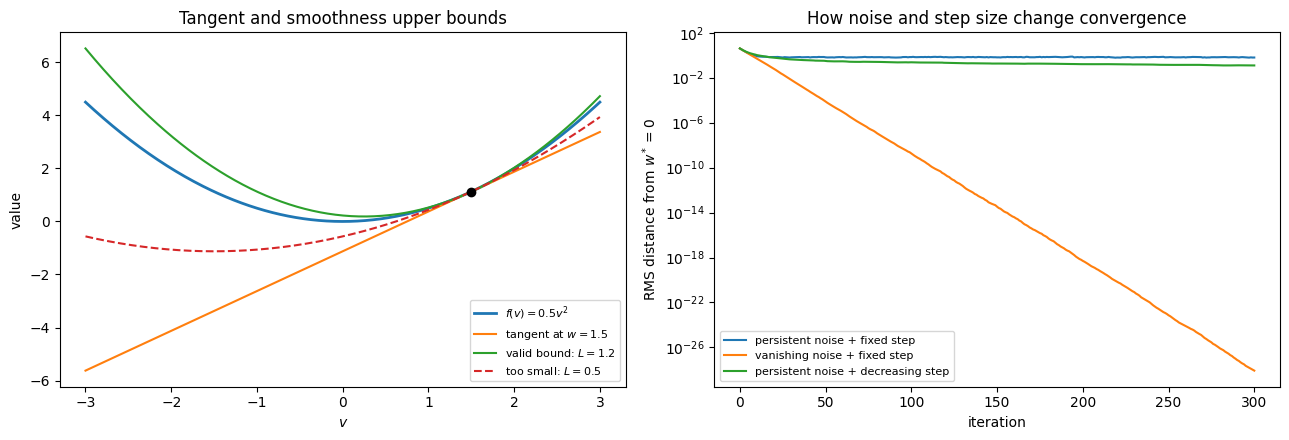

Bonus checks passed.


In [27]:
def run_sgd_convergence_bonus():
    test_seed = SEED + 600
    test_rng = np.random.default_rng(test_seed)
    first_sign = test_rng.choice([-1.0, 1.0])
    expected_first_step = 2.0 - 0.1 * (2.0 + 2.0 * first_sign)
    test_trajectory = run_quadratic_sgd(
        "persistent",
        initial_w=2.0,
        step_sizes=np.array([0.1]),
        seed=test_seed,
    )
    assert test_trajectory.shape == (2,)
    assert np.isclose(test_trajectory[1], expected_first_step)

    expected_vanishing_step = (
        2.0 - 0.1 * ((1.0 + 0.5 * first_sign) * 2.0)
    )
    vanishing_test_trajectory = run_quadratic_sgd(
        "vanishing",
        initial_w=2.0,
        step_sizes=np.array([0.1]),
        seed=test_seed,
    )
    assert np.isclose(
        vanishing_test_trajectory[1],
        expected_vanishing_step,
    )
    assert np.allclose(
        run_quadratic_sgd(
            "vanishing",
            initial_w=0.0,
            step_sizes=np.full(5, 0.2),
            seed=test_seed,
        ),
        0.0,
    )

    steps = 300
    runs = 250
    initial_w = 4.0
    fixed_steps = np.full(steps, 0.2)
    decreasing_steps = 2.0 / (np.arange(steps) + 10.0)

    def simulate(noise_kind, step_sizes):
        return np.stack(
            [
                run_quadratic_sgd(
                    noise_kind,
                    initial_w=initial_w,
                    step_sizes=step_sizes,
                    seed=SEED + 1000 + run_index,
                )
                for run_index in range(runs)
            ]
        )

    trajectories = {
        "persistent noise + fixed step": simulate("persistent", fixed_steps),
        "vanishing noise + fixed step": simulate("vanishing", fixed_steps),
        "persistent noise + decreasing step": simulate(
            "persistent", decreasing_steps
        ),
    }

    summary = pd.DataFrame(
        [
            {
                "experiment": name,
                "final mean iterate": values[:, -1].mean(),
                "final RMS distance": np.sqrt(np.mean(values[:, -1] ** 2)),
                "final mean objective": 0.5 * np.mean(values[:, -1] ** 2),
            }
            for name, values in trajectories.items()
        ]
    )
    display(
        summary.style.format(
            {
                "final mean iterate": "{:.3e}",
                "final RMS distance": "{:.3e}",
                "final mean objective": "{:.3e}",
            }
        )
    )

    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Use the same f(v) = 0.5 v^2 objective as the SGD experiment.
    grid = np.linspace(-3.0, 3.0, 400)
    reference_w = 1.5
    objective = 0.5 * grid**2
    objective_at_reference = 0.5 * reference_w**2
    gradient_at_reference = reference_w
    tangent = objective_at_reference + gradient_at_reference * (grid - reference_w)

    # The smallest valid constant is L=1. We plot L=1.2 so that the valid upper
    # bound is visibly above the objective; every L >= 1 is also valid.
    valid_L = 1.2
    too_small_L = 0.5
    valid_upper_bound = tangent + 0.5 * valid_L * (grid - reference_w) ** 2
    invalid_upper_bound = tangent + 0.5 * too_small_L * (grid - reference_w) ** 2

    axes[0].plot(grid, objective, label="$f(v)=0.5v^2$", linewidth=2)
    axes[0].plot(grid, tangent, label="tangent at $w=1.5$")
    axes[0].plot(grid, valid_upper_bound, label="valid bound: $L=1.2$")
    axes[0].plot(
        grid,
        invalid_upper_bound,
        linestyle="--",
        label="too small: $L=0.5$",
    )
    axes[0].scatter(
        [reference_w],
        [objective_at_reference],
        color="black",
        zorder=3,
    )
    axes[0].set(
        xlabel="$v$",
        ylabel="value",
        title="Tangent and smoothness upper bounds",
    )
    axes[0].legend(fontsize=8)

    iteration = np.arange(steps + 1)
    for name, values in trajectories.items():
        rms_distance = np.sqrt(np.mean(values**2, axis=0))
        axes[1].plot(iteration, rms_distance, label=name)
    axes[1].set(
        xlabel="iteration",
        ylabel="RMS distance from $w^*=0$",
        title="How noise and step size change convergence",
    )
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    print("Bonus checks passed.")


if RUN_BONUS:
    run_sgd_convergence_bonus()
else:
    print("Bonus skipped. Set RUN_BONUS = True after completing Task 6.1.")

### Bonus Task 2 — Explain what the experiment shows

Use the guided derivation and plots as evidence. You do not need to reproduce the algebra.

1. In the first plot, what does the tangent predict, and what does the quadratic term add? Explain
   why $L=1.2$ gives a valid upper bound while $L=0.5$ is too small for this objective.
2. In the guided derivation, what does unbiasedness let us replace, and what does the variance
   identity let us replace? Why do we condition on the current $\mathbf w_t$?
3. Both stochastic gradients are unbiased. What values can each one produce at $w=0$, and how
   does this explain the different fixed-step curves? In the persistent-noise fixed-step row, why
   can the final mean iterate be close to zero while the final RMS distance remains positive? Which
   quantity better reveals whether individual runs have settled at the optimum?
4. Within the stable small-step range used here, $0<\eta_t\leq1/L$, how does reducing $\eta_t$
   affect useful progress and the noise penalty? How does this explain the fixed-step trade-off?
5. What failure is each Robbins–Monro condition intended to prevent? How does the decreasing-step
   curve reflect their shared purpose? You do not need to prove that an infinite series converges.

This scalar convex example illustrates mechanisms, not a proof that SGD will reach a global minimum
for an arbitrary deep network.

#### Your answer